# Dataset: FICO

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("data/GiveMeSomeCredit/cs-training.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [34]:
df.shape

(150000, 12)

In [35]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [43]:
df.drop('SeriousDlqin2yrs', axis=1, inplace=True)

In [44]:
df.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [45]:
df.describe()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [51]:
# Check correlation of SeriousDlqin2yrs with other features
correlation = df.corr()
correlation

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
RevolvingUtilizationOfUnsecuredLines,1.000000,-0.005898,-0.001314,0.003961,0.007124,-0.011281,-0.001061,0.006235,-0.001048,0.001557
age,-0.005898,1.000000,-0.062995,0.024188,0.037717,0.147705,-0.061005,0.033150,-0.057159,-0.213303
NumberOfTime30-59DaysPastDueNotWorse,-0.001314,-0.062995,1.000000,-0.006542,-0.010217,-0.055312,0.983603,-0.030565,0.987005,-0.002680
DebtRatio,0.003961,0.024188,-0.006542,1.000000,-0.028712,0.049565,-0.008320,0.120046,-0.007533,-0.040673
MonthlyIncome,0.007124,0.037717,-0.010217,-0.028712,1.000000,0.091455,-0.012743,0.124959,-0.011116,0.062647
NumberOfOpenCreditLinesAndLoans,-0.011281,0.147705,-0.055312,0.049565,0.091455,1.000000,-0.079984,0.433959,-0.071077,0.065322
NumberOfTimes90DaysLate,-0.001061,-0.061005,0.983603,-0.008320,-0.012743,-0.079984,1.000000,-0.045205,0.992796,-0.010176
NumberRealEstateLoansOrLines,0.006235,0.033150,-0.030565,0.120046,0.124959,0.433959,-0.045205,1.000000,-0.039722,0.124684
NumberOfTime60-89DaysPastDueNotWorse,-0.001048,-0.057159,0.987005,-0.007533,-0.011116,-0.071077,0.992796,-0.039722,1.000000,-0.010922
NumberOfDependents,0.001557,-0.213303,-0.002680,-0.040673,0.062647,0.065322,-0.010176,0.124684,-0.010922,1.000000


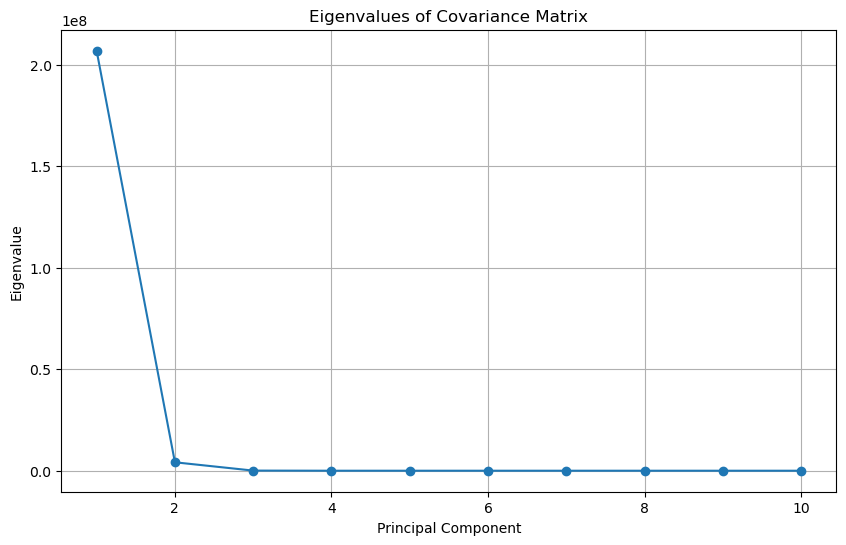

In [47]:
# Get covariance matrix, eigenvalues, and eigenvectors
cov_matrix = df.cov()
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Plot eigenvalues to visualize variance explained by each principal component
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.title('Eigenvalues of Covariance Matrix')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

In [48]:
normalized_eigenvalues = np.round(eigenvalues / np.sum(eigenvalues), 4)
cumsum = np.cumsum(normalized_eigenvalues)
print("Eigenvalues:\n", eigenvalues)
print("Normalized Eigenvalues:\n", normalized_eigenvalues)
print("Cumulative Sum of Normalized Eigenvalues:\n", cumsum)

Eigenvalues:
 [2.06919008e+08 4.15255401e+06 6.23733879e+04 2.18700437e+02
 5.17210526e+01 2.56422939e+01 1.22146526e+00 9.49459958e-01
 1.17901823e-01 3.01092090e-01]
Normalized Eigenvalues:
 [9.80e-01 1.97e-02 3.00e-04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00]
Cumulative Sum of Normalized Eigenvalues:
 [0.98   0.9997 1.     1.     1.     1.     1.     1.     1.     1.    ]


In [49]:
# Add columns to eigenvectors for better readability
eigenvector_df = pd.DataFrame(eigenvectors, index=cov_matrix.index)
eigenvector_df.columns = [f'PC{i+1}' for i in range(eigenvectors.shape[1])]
eigenvector_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
RevolvingUtilizationOfUnsecuredLines,-0.000127,0.000498,1.000000,0.000384,0.000026,-0.000229,-0.000024,0.000038,1.416628e-06,-1.217052e-06
age,-0.000038,0.000177,-0.000372,0.997487,0.043514,0.053050,0.016845,0.005011,7.364671e-04,-1.190437e-03
NumberOfTime30-59DaysPastDueNotWorse,0.000002,-0.000014,-0.000021,-0.023326,0.576177,-0.059846,0.018794,-0.001748,1.487935e-01,-8.008738e-01
DebtRatio,0.000865,0.999999,-0.000498,-0.000185,0.000030,0.000120,-0.000006,0.000058,-7.116982e-08,4.978098e-07
MonthlyIncome,-1.000000,0.000864,-0.000128,-0.000040,0.000006,0.000031,-0.000007,0.000004,1.107735e-07,-2.419572e-07
NumberOfOpenCreditLinesAndLoans,-0.000033,0.000127,-0.000251,0.056842,-0.080346,-0.990070,-0.062523,0.077373,1.979315e-03,1.325692e-02
NumberOfTimes90DaysLate,0.000003,-0.000017,-0.000016,-0.022746,0.574957,-0.038695,-0.007581,0.005454,6.197832e-01,5.321574e-01
NumberRealEstateLoansOrLines,-0.000010,0.000067,0.000022,0.002630,-0.009354,-0.096410,0.438527,-0.893366,4.423362e-03,1.346034e-02
NumberOfTime60-89DaysPastDueNotWorse,0.000003,-0.000015,-0.000016,-0.021568,0.573573,-0.045564,-0.006742,-0.004157,-7.705015e-01,2.733818e-01
NumberOfDependents,-0.000005,-0.000021,0.000006,-0.015937,-0.004751,-0.022311,0.896128,0.442532,-5.714288e-03,1.771485e-02


In [50]:
# Select PC1 and PC2 columns as their own variables
pc1 = eigenvector_df['PC1']
pc2 = eigenvector_df['PC2']

# Cumsums of PC1 and PC2 columns each to see which attributes contribute the most
pc1_cumsum = np.cumsum(np.abs(pc1))
pc2_cumsum = np.cumsum(np.abs(pc2))
print("Cumulative Sum of Absolute Values for PC1:\n", pc1_cumsum)
print("Cumulative Sum of Absolute Values for PC2:\n", pc2_cumsum)

Cumulative Sum of Absolute Values for PC1:
 RevolvingUtilizationOfUnsecuredLines    0.000127
age                                     0.000165
NumberOfTime30-59DaysPastDueNotWorse    0.000168
DebtRatio                               0.001032
MonthlyIncome                           1.001032
NumberOfOpenCreditLinesAndLoans         1.001065
NumberOfTimes90DaysLate                 1.001068
NumberRealEstateLoansOrLines            1.001078
NumberOfTime60-89DaysPastDueNotWorse    1.001080
NumberOfDependents                      1.001085
Name: PC1, dtype: float64
Cumulative Sum of Absolute Values for PC2:
 RevolvingUtilizationOfUnsecuredLines    0.000498
age                                     0.000675
NumberOfTime30-59DaysPastDueNotWorse    0.000689
DebtRatio                               1.000688
MonthlyIncome                           1.001553
NumberOfOpenCreditLinesAndLoans         1.001680
NumberOfTimes90DaysLate                 1.001697
NumberRealEstateLoansOrLines            1.001764
Numb